# EDA Project 2

Mental Health in Tech Analysis

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mental-health-in-tech-survey' dataset.
Path to dataset files: /kaggle/input/mental-health-in-tech-survey


In [ ]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Getting the data
data = pd.read_csv('/kaggle/input/mental-health-in-tech-survey/survey.csv')

In [ ]:
# Converting the data into the dataframe
df = pd.DataFrame(data)
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# Checking the columns
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [ ]:
# Checking the nulls in the dataframe
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [ ]:
# Inspecting the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [ ]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [ ]:
df = df[(df['Age'] > 17) & (df['Age'] < 100)]
df['Age'].describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


In [ ]:
# dropping the unecessary columns
df.drop(columns=['comments'], inplace=True)

In [ ]:
# Removing the null rows
df.dropna(inplace=True)

In [ ]:
# Again checking the null values
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


In [ ]:
# Checking the dataframe now
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
18,2014-08-27 11:34:53,46,male,United States,MD,Yes,Yes,No,Sometimes,1-5,...,Yes,Very easy,No,No,Yes,Yes,No,Yes,Yes,Yes
20,2014-08-27 11:35:12,29,Male,United States,NY,No,Yes,Yes,Sometimes,100-500,...,No,Somewhat difficult,Maybe,No,Some of them,Some of them,No,No,No,No
21,2014-08-27 11:35:24,31,male,United States,NC,Yes,No,No,Never,1-5,...,Yes,Somewhat difficult,No,No,Some of them,Some of them,No,Maybe,Yes,No
22,2014-08-27 11:35:48,46,Male,United States,MA,No,No,Yes,Often,26-100,...,Don't know,Don't know,Maybe,No,Some of them,Yes,No,Maybe,No,No
23,2014-08-27 11:36:24,41,Male,United States,IA,No,No,Yes,Never,More than 1000,...,Don't know,Don't know,Maybe,No,No,No,No,Yes,Don't know,No


In [ ]:
df['Year'] = df['Timestamp'].apply(lambda x: x.split('-')[0])
df['Month'] = df['Timestamp'].apply(lambda x: x.split('-')[1])

In [ ]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Year,Month
18,2014-08-27 11:34:53,46,male,United States,MD,Yes,Yes,No,Sometimes,1-5,...,No,No,Yes,Yes,No,Yes,Yes,Yes,2014,08
20,2014-08-27 11:35:12,29,Male,United States,NY,No,Yes,Yes,Sometimes,100-500,...,Maybe,No,Some of them,Some of them,No,No,No,No,2014,08
21,2014-08-27 11:35:24,31,male,United States,NC,Yes,No,No,Never,1-5,...,No,No,Some of them,Some of them,No,Maybe,Yes,No,2014,08
22,2014-08-27 11:35:48,46,Male,United States,MA,No,No,Yes,Often,26-100,...,Maybe,No,Some of them,Yes,No,Maybe,No,No,2014,08
23,2014-08-27 11:36:24,41,Male,United States,IA,No,No,Yes,Never,More than 1000,...,Maybe,No,No,No,No,Yes,Don't know,No,2014,08


## Demographic Analysis

Age Distribution

In [ ]:
df['Age'].value_counts().sort_values(ascending=False)

,count
Age,
32,40
29,34
33,33
26,31
35,31
28,30
30,29
25,29
31,29


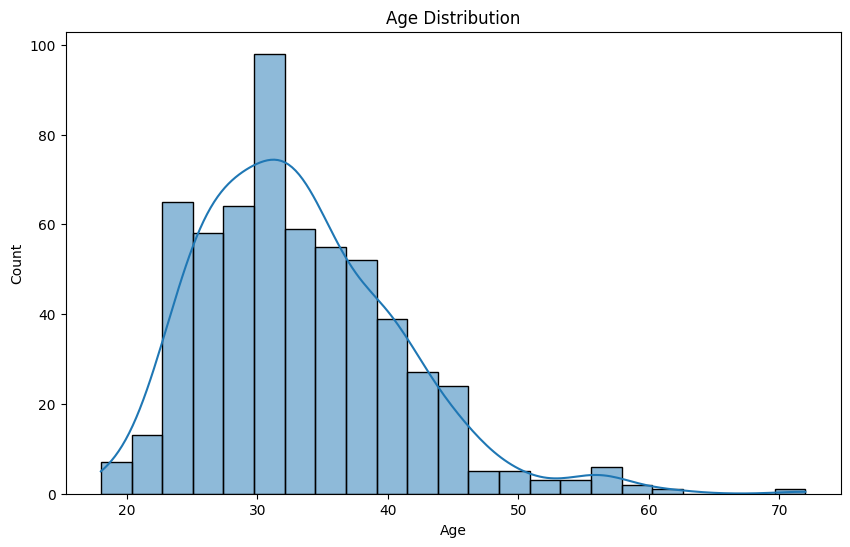

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Gender Distribution

In [ ]:
# Replacing the gender values and find it's distribution
df['Gender'] = df['Gender'].replace({'male': 'Male', 'M': 'Male', 'm': 'Male', 'Mail': 'Male', 'Make': 'Male', 'Cis Male': 'Male', 'Male-ish': 'Male', 'Nah': 'Male', 'msle': 'Male', 'non-binary': 'Male', 'Mail': 'Male', 'cis male': 'Male', 'female': 'Female', 'F': 'Female', 'f': 'Female', 'Female (trans)': 'Female', 'Cis Female': 'Female', 'queer/she/they': 'Female', 'Trans-female': 'Female', 'woman': 'Female', 'Genderqueer': 'Female', 'cis-female/femme': 'Female', 'Trans woman': 'Female', 'Female (cis)': 'Female', 'Woman': 'Female', 'femail': 'Female'}).str.strip()
df['Gender'].value_counts()

,count
Gender,
Male,434
Female,153


/tmp/ipython-input-2873918428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Gender'], palette='viridis')


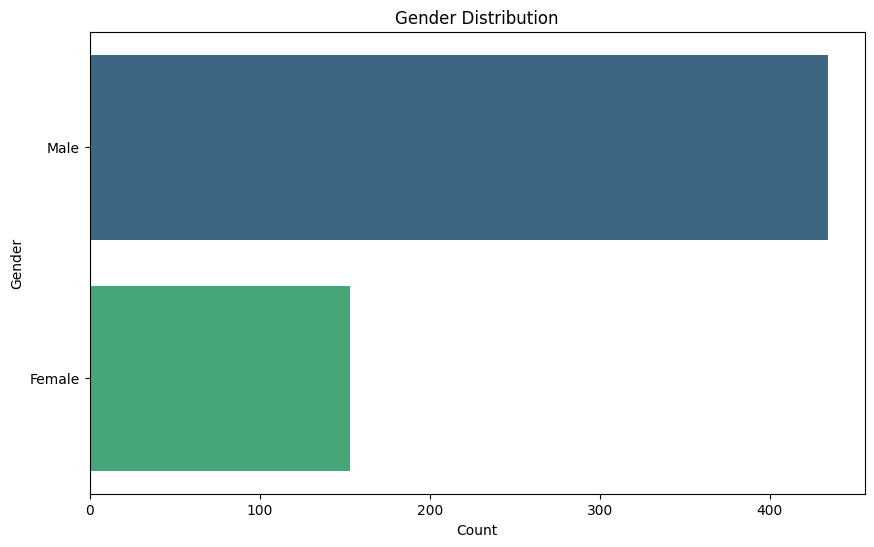

In [ ]:
# plotting the distribution
plt.figure(figsize=(10, 6))
sns.countplot(df['Gender'], palette='viridis')
plt.title('Gender Distribution')
plt.xlabel('Count')
plt.ylabel('Gender')
plt.show()

Country Distribution

In [ ]:
df['Country'].value_counts()

,count
Country,
United States,585
Israel,1
Bulgaria,1


/tmp/ipython-input-366234101.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Country'], palette='viridis')


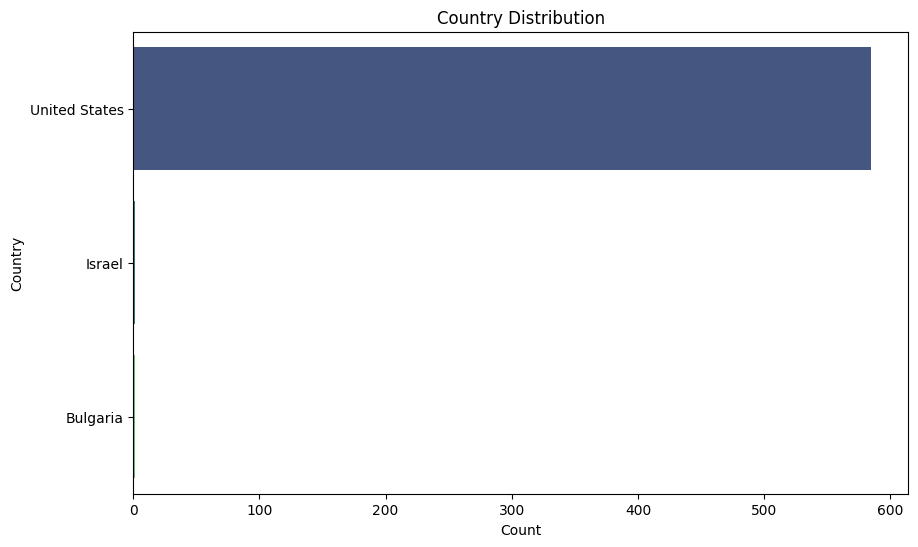

In [ ]:
# plotting the country distribution
plt.figure(figsize=(10, 6))
sns.countplot(df['Country'], palette='viridis')
plt.title('Country Distribution')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

Role of Age in seeking Treatment

In [ ]:
bins = [18, 28, 38, 48, 58, 68, 72]
labels = ['18-28', '29-38', '39-48', '48-58', '58-68', '68-72']
df['Age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

pd.crosstab(df['Age_group'], df['treatment'], normalize='index') * 100

treatment,No,Yes
Age_group,,
18-28,28.235294,71.764706
29-38,35.335689,64.664311
39-48,30.909091,69.090909
48-58,38.888889,61.111111
58-68,50.000000,50.000000
68-72,0.000000,100.000000


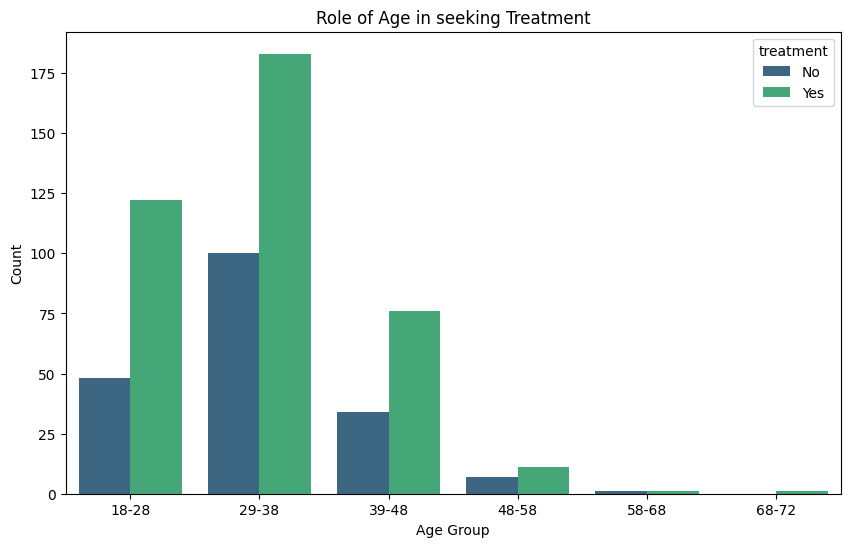

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['Age_group'], hue=df['treatment'], palette='viridis')
plt.title('Role of Age in seeking Treatment')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

## Mental Health Treatment and Workplace Factors

Treatment Correlation with Employment Factors



treatment          No    Yes
family_history              
No              47.10  52.90
Yes             18.03  81.97


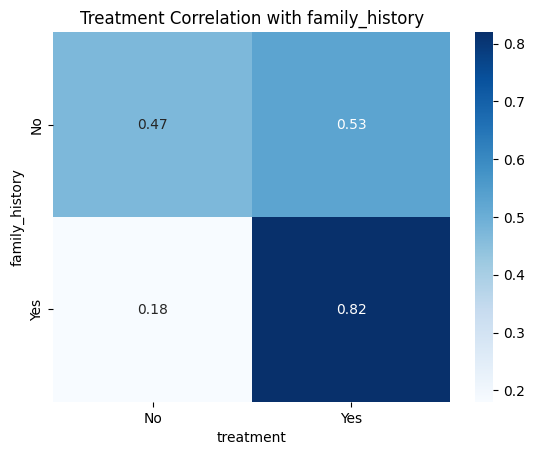



treatment         No    Yes
self_employed              
No             32.04  67.96
Yes            38.30  61.70


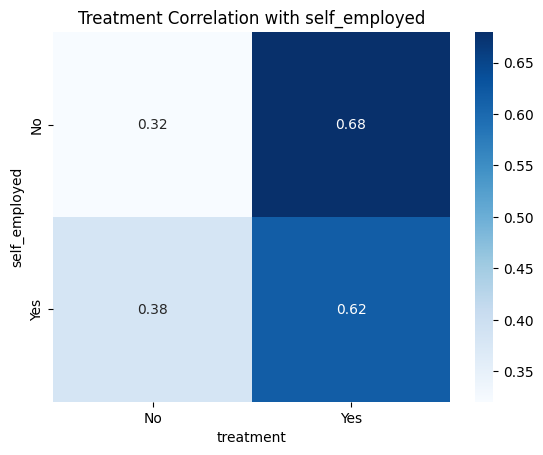



treatment       No    Yes
remote_work              
No           33.75  66.25
Yes          29.89  70.11


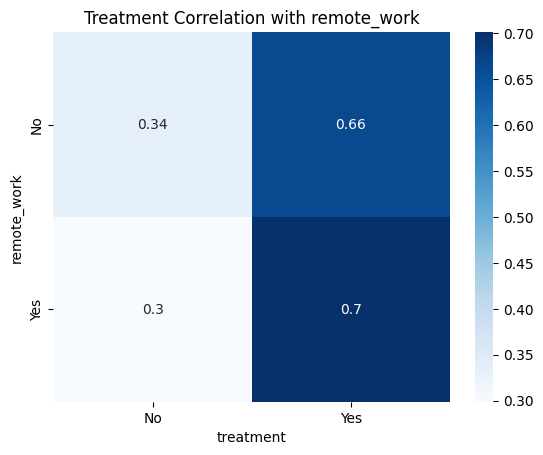



treatment        No    Yes
tech_company              
No            31.43  68.57
Yes           32.78  67.22


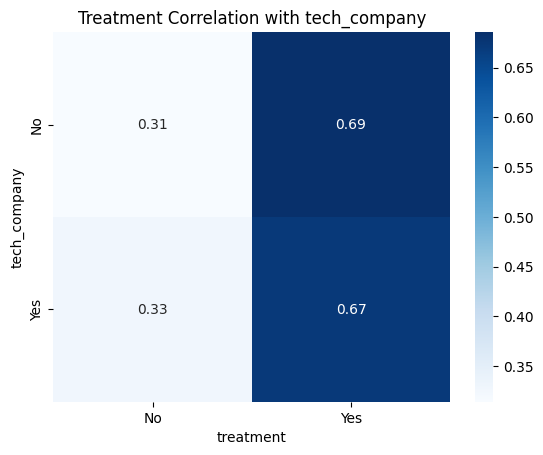



treatment          No    Yes
no_employees                
1-5             34.85  65.15
100-500         31.11  68.89
26-100          27.94  72.06
500-1000        30.00  70.00
6-25            35.00  65.00
More than 1000  35.15  64.85


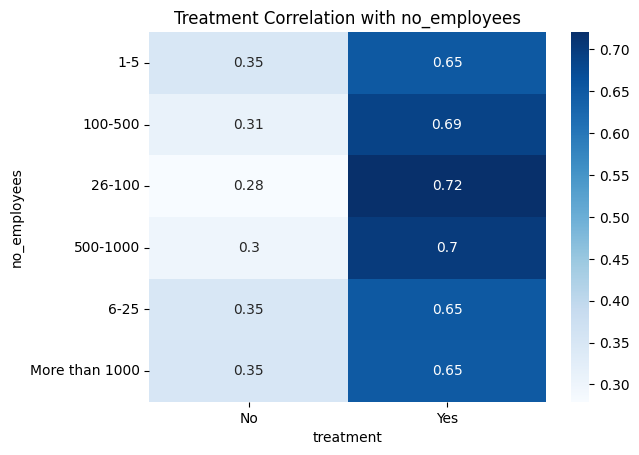

In [ ]:
factors = ['family_history', 'self_employed', 'remote_work', 'tech_company', 'no_employees']

for factor in factors:
  print("\n")
  print(pd.crosstab(df[factor], df['treatment'], normalize='index').round(4) * 100)
  sns.heatmap(pd.crosstab(df[factor], df['treatment'], normalize='index') , annot=True, cmap='Blues')
  plt.title(f"Treatment Correlation with {factor}")
  plt.show()

Impact of company size on experiencing work_interfere

In [ ]:
pd.crosstab(df['work_interfere'], df['no_employees'], normalize='index').round(4) * 100

no_employees,1-5,100-500,26-100,500-1000,6-25,More than 1000
work_interfere,,,,,,
Never,10.00,14.17,23.33,9.17,14.17,29.17
Often,15.38,11.54,23.08,1.28,20.51,28.21
Rarely,9.35,15.89,13.08,5.61,23.36,32.71
Sometimes,11.35,16.67,26.95,4.26,14.89,25.89


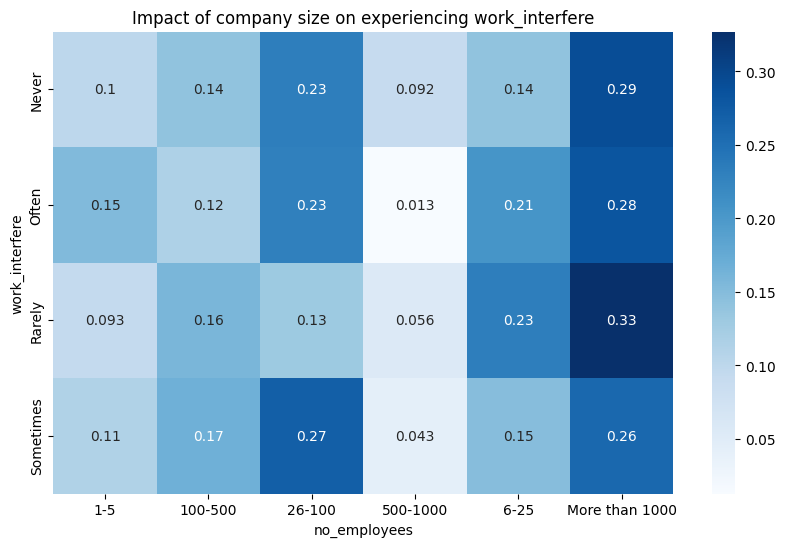

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df['work_interfere'], df['no_employees'], normalize='index'), annot=True, cmap='Blues')
plt.title('Impact of company size on experiencing work_interfere')
plt.xlabel('no_employees')
plt.ylabel('work_interfere')
plt.show()

Impact of company size on seeking treatment

In [ ]:
pd.crosstab(df['treatment'], df['no_employees'], normalize='index').round(4) * 100

no_employees,1-5,100-500,26-100,500-1000,6-25,More than 1000
treatment,,,,,,
No,12.04,14.66,19.90,4.71,18.32,30.37
Yes,10.86,15.66,24.75,5.30,16.41,27.02


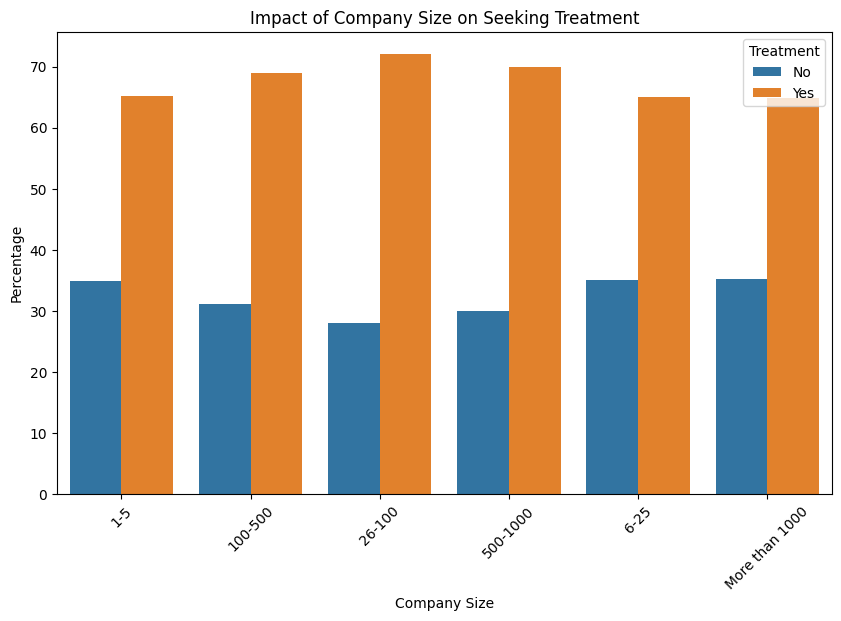

In [ ]:
# Create crosstab
ct = pd.crosstab(df['no_employees'], df['treatment'], normalize='index') * 100

# Reshape for seaborn
ct = ct.reset_index().melt(id_vars='no_employees', var_name='Treatment', value_name='Percent')

# Plot side-by-side bars
plt.figure(figsize=(10, 6))
sns.barplot(data=ct, x='no_employees', y='Percent', hue='Treatment')
plt.title('Impact of Company Size on Seeking Treatment')
plt.xlabel('Company Size')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Treatment')
plt.show()

Relation of employer support mechanisms with treatment

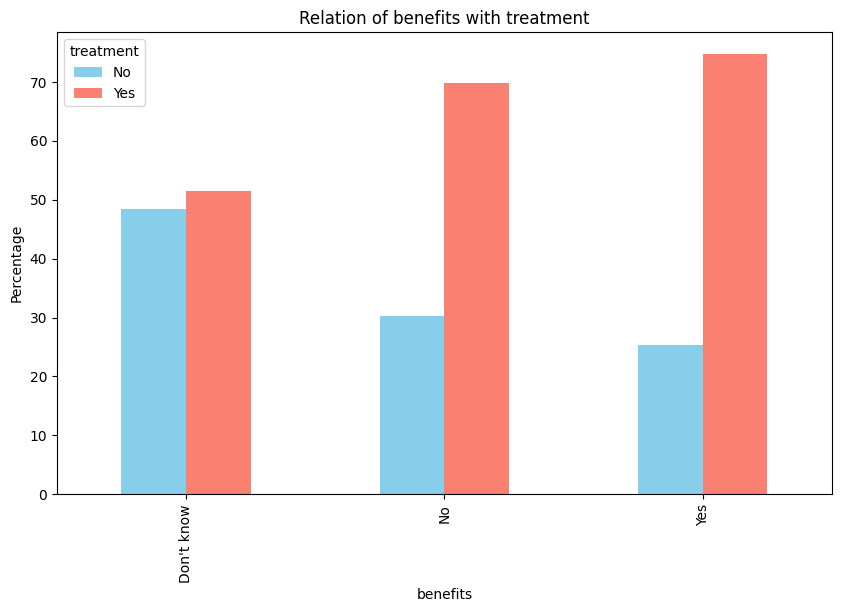

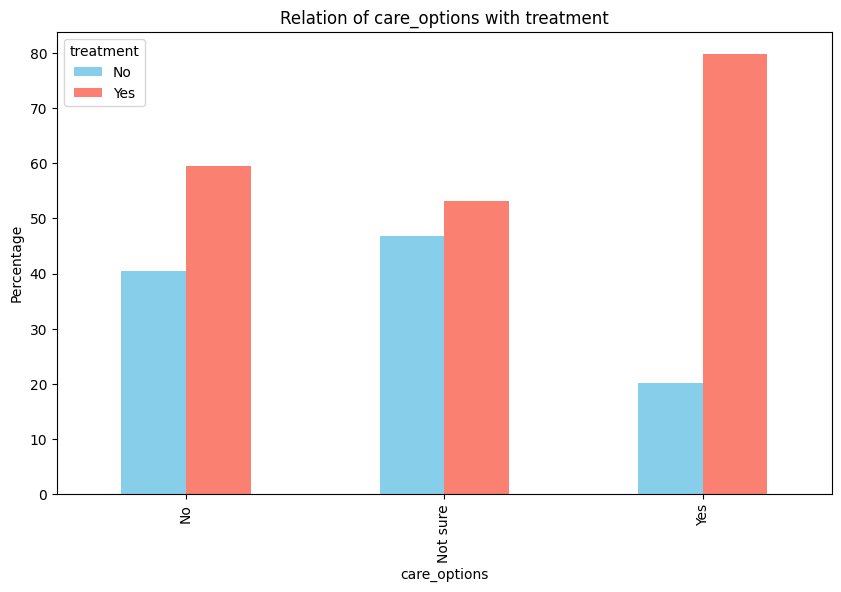

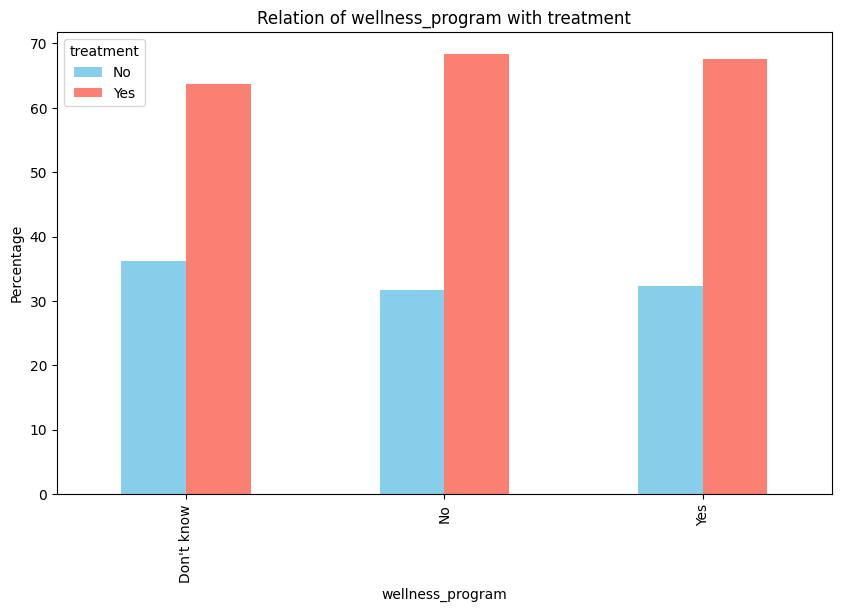

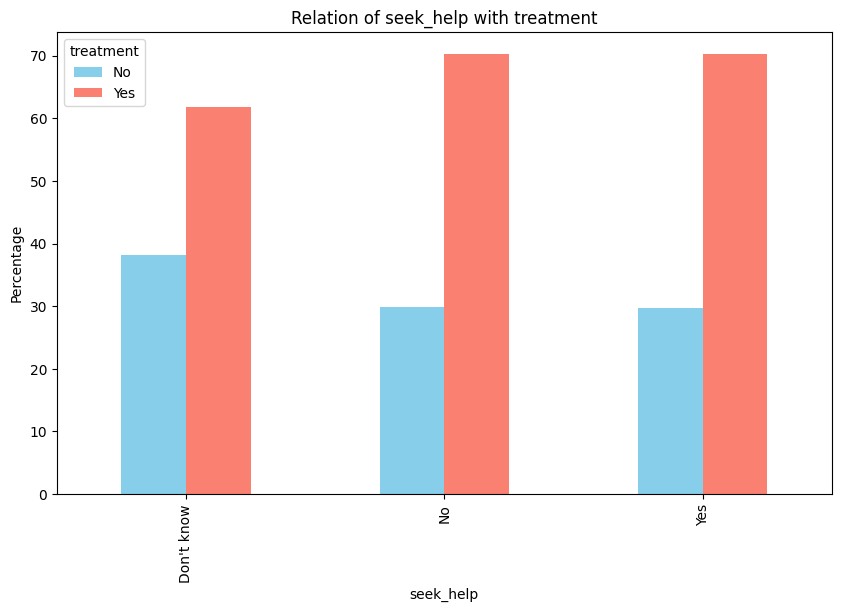

In [ ]:
factors = ['benefits', 'care_options', 'wellness_program', 'seek_help']

for factor in factors:
  print("\n")
  ct = pd.crosstab(df[factor], df['treatment'], normalize='index').round(4) * 100
  ct.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
  plt.title(f"Relation of {factor} with treatment")
  plt.xlabel(factor)
  plt.ylabel('Percentage')
  plt.show()


## Workplace Culture and Support

Influence of Colleagues in seeking treatment

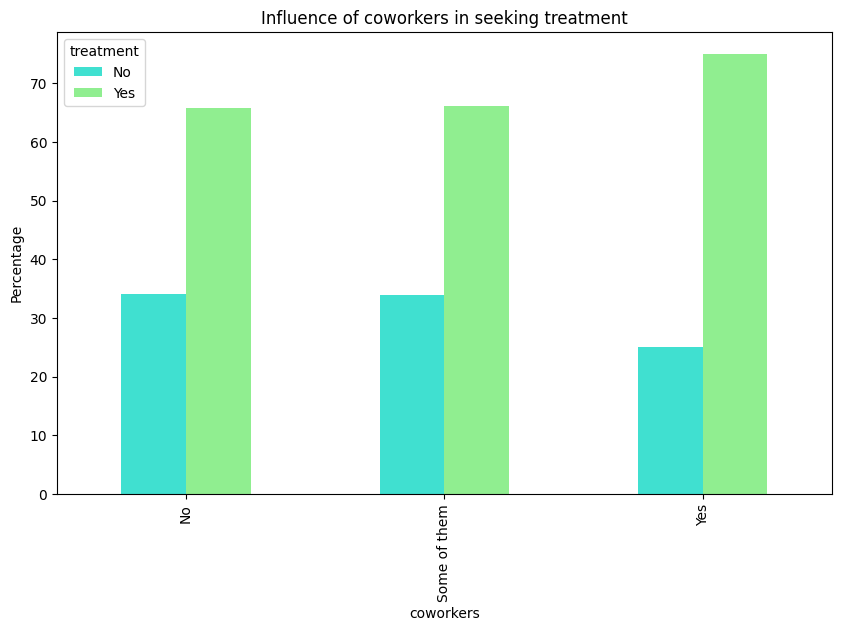

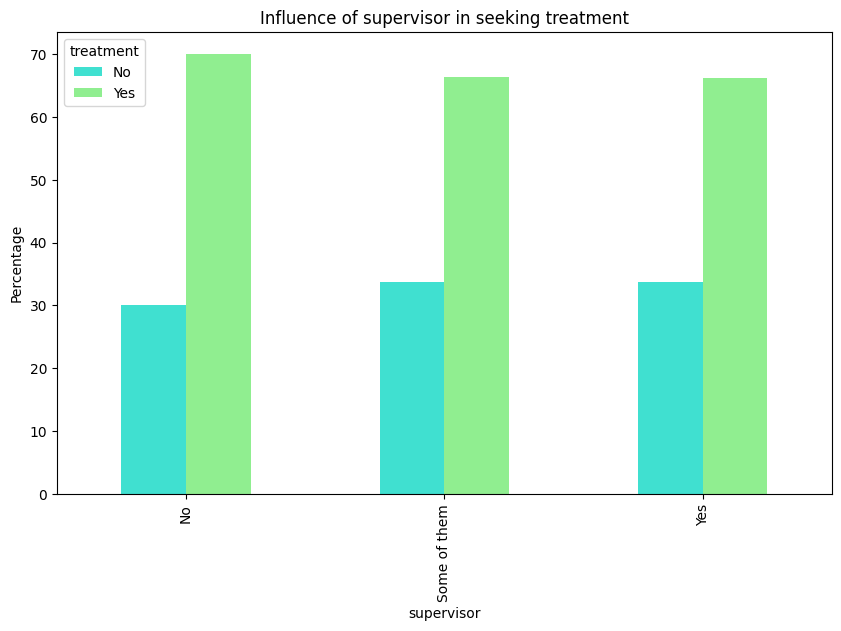

In [157]:
for colleagues in ['coworkers', 'supervisor']:
  print("\n")
  colleagues_inf = pd.crosstab(df[colleagues], df['treatment'], normalize='index').round(4) * 100
  colleagues_inf.plot(kind='bar', figsize=(10, 6), color=['turquoise', 'lightgreen'])
  plt.title(f"Influence of {colleagues} in seeking treatment")
  plt.xlabel(colleagues)
  plt.ylabel('Percentage')
  plt.show()

Influence of Colleagues in seeking Mental Health Consequence

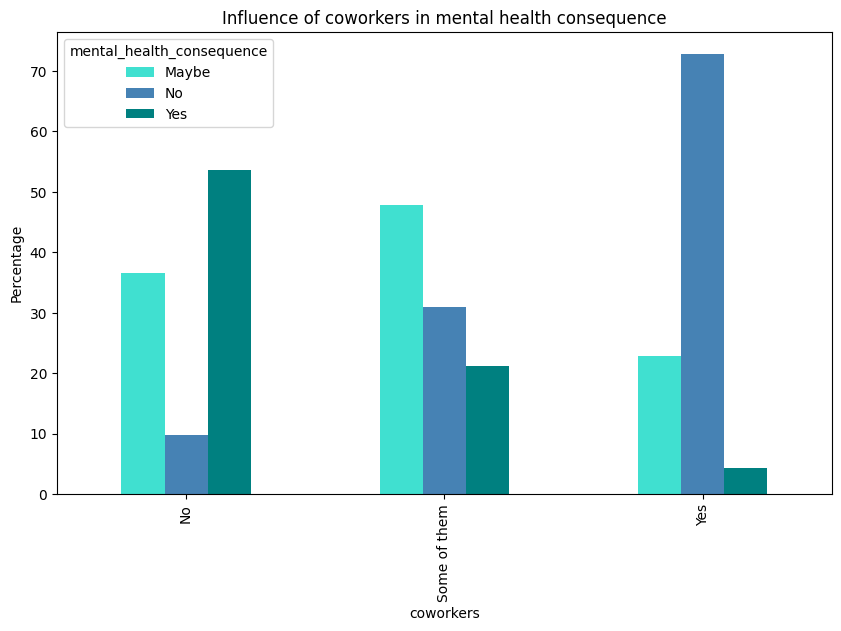

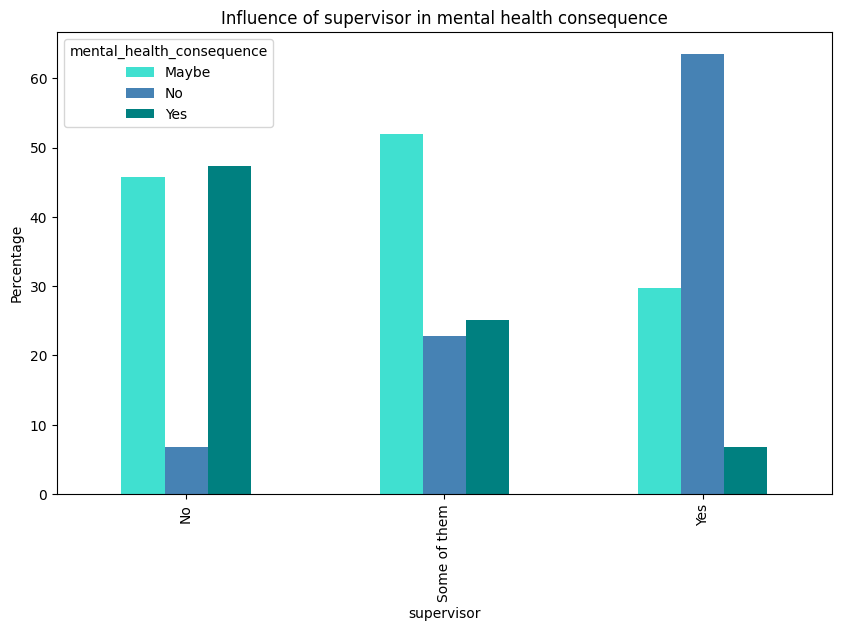

In [168]:
for colleagues in ['coworkers', 'supervisor']:
  print("\n")
  colleagues_inf = pd.crosstab(df[colleagues], df['mental_health_consequence'], normalize='index').round(4) * 100
  colleagues_inf.plot(kind='bar', figsize=(10, 6), color=['turquoise', 'steelblue', 'teal'])
  plt.title(f"Influence of {colleagues} in mental health consequence")
  plt.xlabel(colleagues)
  plt.ylabel('Percentage')
  plt.show()

 Anonymity Perception

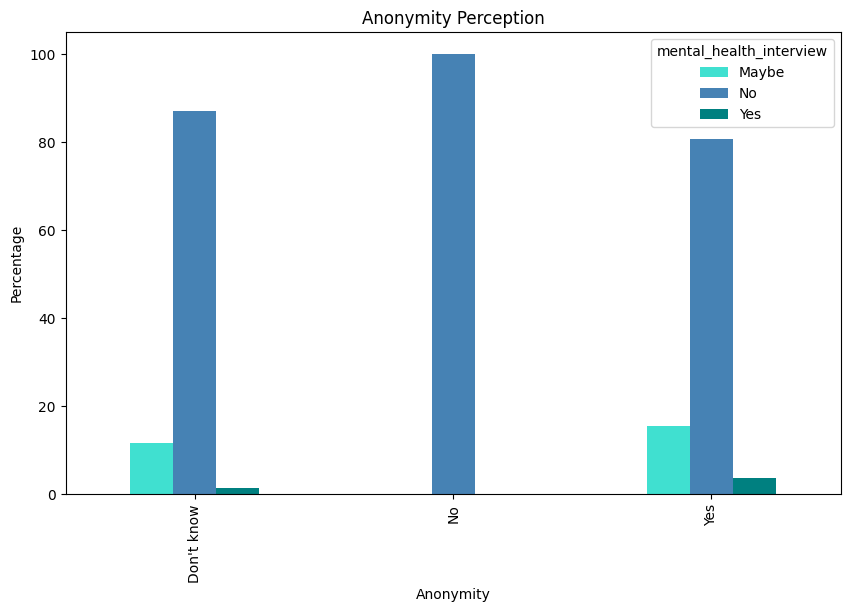

In [170]:
anonymity = pd.crosstab(df['anonymity'], df['mental_health_interview'], normalize='index').round(4) * 100
anonymity.plot(kind='bar', figsize=(10, 6), color=['turquoise', 'steelblue', 'teal'])
plt.title(f"Anonymity Perception")
plt.xlabel('Anonymity')
plt.ylabel('Percentage')
plt.show()

Leave Policies Impact

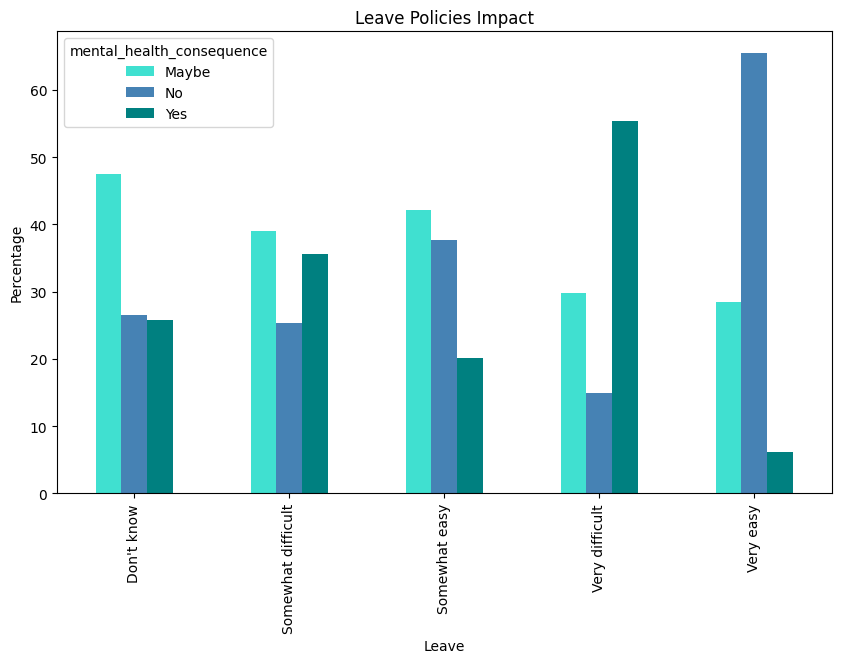

In [173]:
leave = pd.crosstab(df['leave'], df['mental_health_consequence'], normalize='index').round(4) * 100
leave.plot(kind='bar', figsize=(10, 6), color=['turquoise', 'steelblue', 'teal'])
plt.title(f"Leave Policies Impact")
plt.xlabel('Leave')
plt.ylabel('Percentage')
plt.show()

Mental vs. Physical Health Perception


Analyzing: mental_vs_physical vs mental_health_consequence
mental_health_consequence      Maybe         No        Yes
mental_vs_physical                                        
Don't know                 48.727273  27.636364  23.636364
No                         40.506329  11.392405  48.101266
Yes                        29.870130  64.935065   5.194805


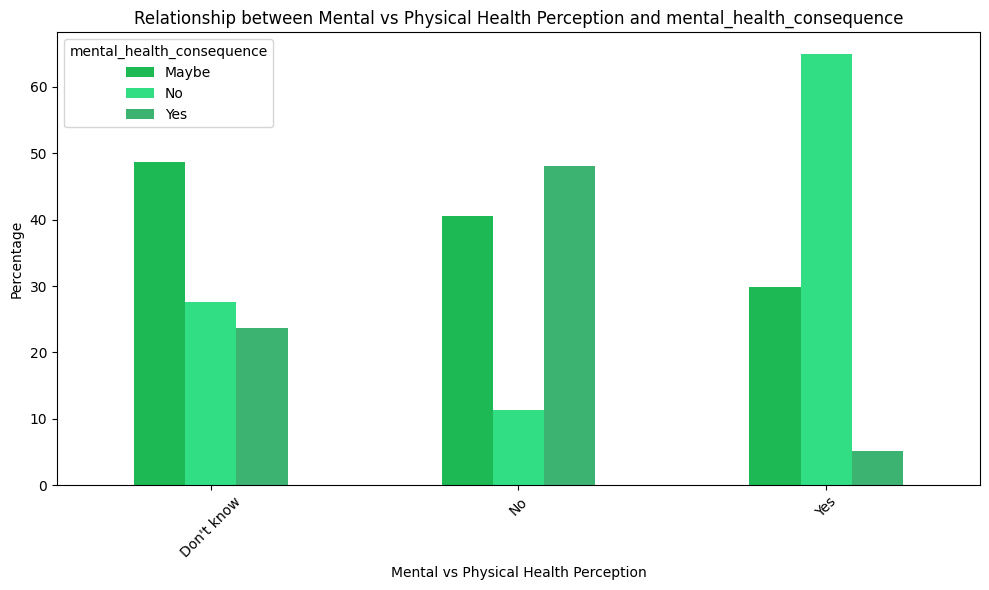


Analyzing: mental_vs_physical vs phys_health_consequence
phys_health_consequence      Maybe         No       Yes
mental_vs_physical                                     
Don't know               23.636364  72.727273  3.636364
No                       29.113924  61.392405  9.493671
Yes                       9.740260  90.259740  0.000000


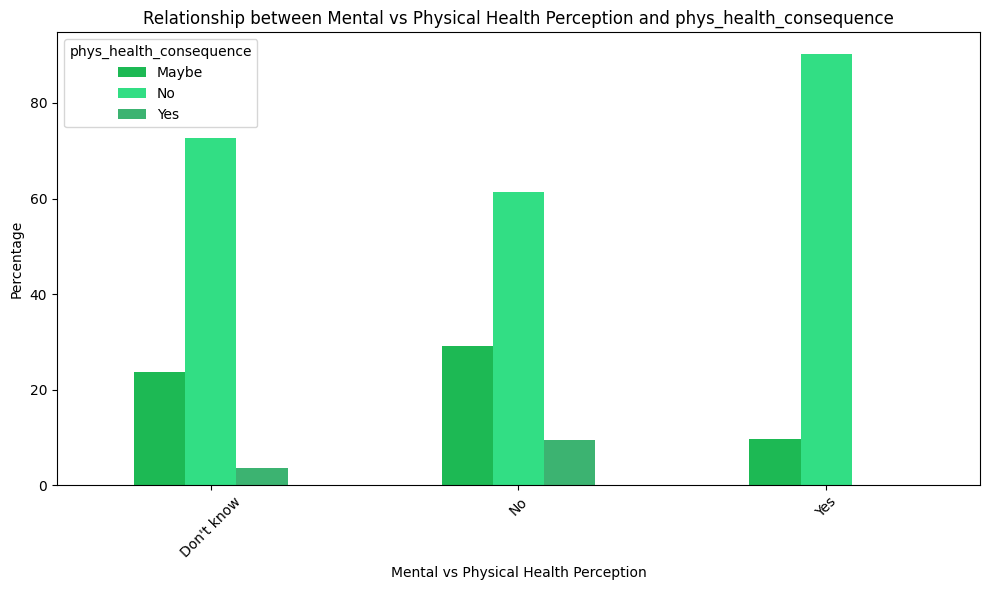


Analyzing: mental_vs_physical vs treatment
treatment                  No        Yes
mental_vs_physical                      
Don't know          35.636364  64.363636
No                  25.949367  74.050633
Yes                 33.766234  66.233766


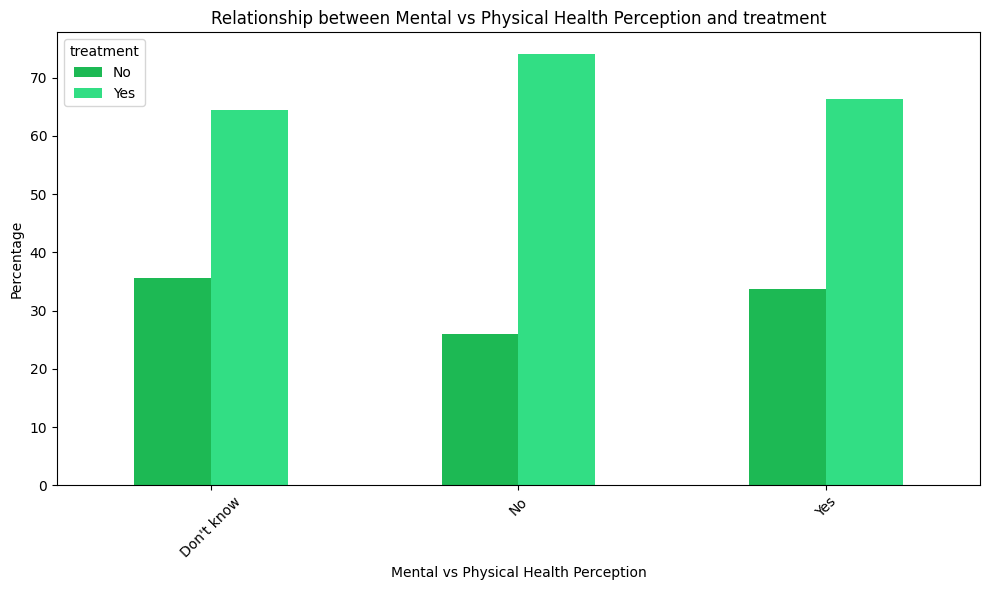

In [178]:
outcomes = ['mental_health_consequence', 'phys_health_consequence', 'treatment']

for outcome in outcomes:
  print(f"\nAnalyzing: mental_vs_physical vs {outcome}")
  crosstab_df = pd.crosstab(df['mental_vs_physical'], df[outcome], normalize='index') * 100
  print(crosstab_df)

  # Plotting the bar chart
  crosstab_df.plot(kind='bar', figsize=(10, 6), color=['#1DB954', '#32de84', '#3CB371'])
  plt.title(f'Relationship between Mental vs Physical Health Perception and {outcome}')
  plt.xlabel('Mental vs Physical Health Perception')
  plt.ylabel('Percentage')
  plt.xticks(rotation=45)
  plt.legend(title=outcome)
  plt.tight_layout()
  plt.show()

## Mental Health Outcomes and Consequences

Distribution of Mental Health Consequence

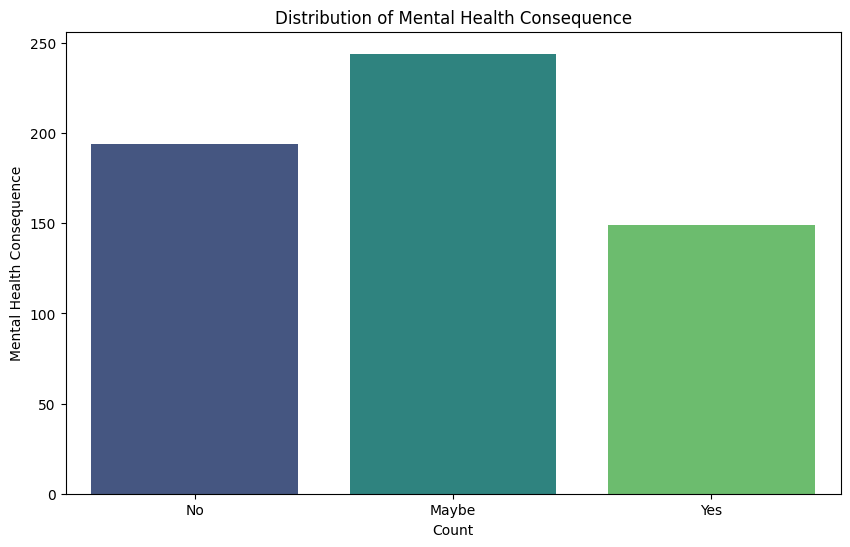

In [181]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['mental_health_consequence'], hue=df['mental_health_consequence'], palette='viridis')
plt.title('Distribution of Mental Health Consequence')
plt.xlabel('Count')
plt.ylabel('Mental Health Consequence')
plt.show()

Distribution of Physical Health Consequence

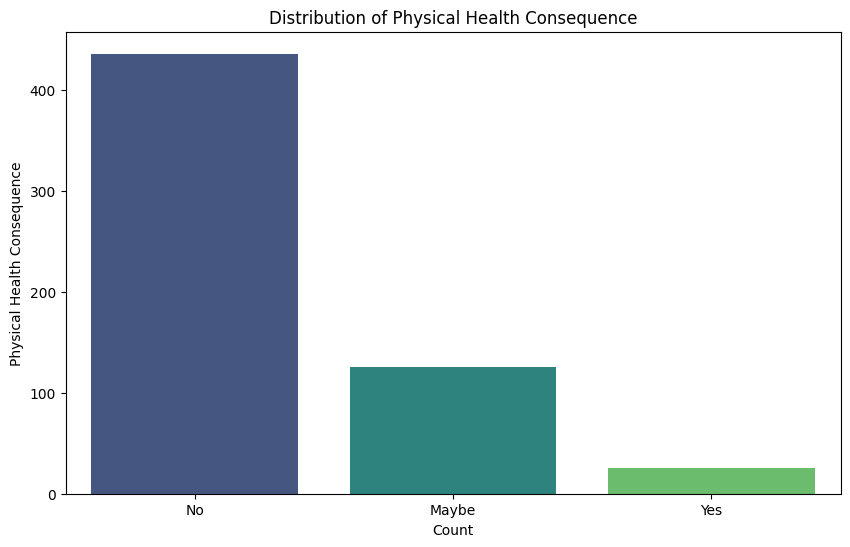

In [183]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['phys_health_consequence'], hue=df['phys_health_consequence'], palette='viridis')
plt.title('Distribution of Physical Health Consequence')
plt.xlabel('Count')
plt.ylabel('Physical Health Consequence')
plt.show()

Frequency of Obs_Consequences

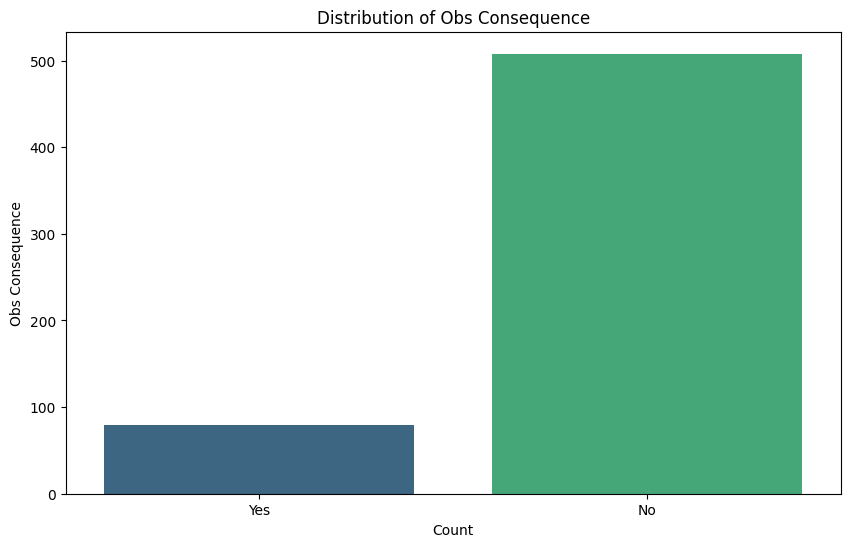

In [184]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['obs_consequence'], hue=df['obs_consequence'], palette='viridis')
plt.title('Distribution of Obs Consequence')
plt.xlabel('Count')
plt.ylabel('Obs Consequence')
plt.show()

## Summarize Demographic Analysis Insights

### Age Distribution

From the `df['Age'].value_counts()` output, the most frequently reported ages are 32, 29, 33, 26, 35, 28, 30, 25, 31, and 27. These ages suggest a concentration of respondents in their late 20s and early 30s. The histogram confirms this, showing a distribution skewed towards younger adults, with the highest counts appearing in the 25-35 age range and a gradual decrease as age increases.

### Gender Distribution

The `df['Gender'].value_counts()` output clearly indicates that **Male** is the predominant gender among the respondents, with 434 entries, significantly outnumbering **Female** respondents, which account for 153 entries. This disparity is visually represented in the countplot.

### Country Distribution

The `df['Country'].value_counts()` output shows a heavily concentrated geographical representation. The **United States** has the overwhelming majority of respondents with 585 entries. In contrast, Israel and Bulgaria each have only 1 respondent. This indicates that the dataset is predominantly focused on mental health in tech professionals within the United States.

### Role of Age in seeking Treatment

Analyzing the crosstab `pd.crosstab(df['Age_group'], df['treatment'], normalize='index') * 100` :

*   The **18-28** age group shows a high percentage of individuals seeking treatment (71.76%).
*   The **29-38** age group also has a significant portion seeking treatment (64.66%).
*   The **39-48** age group has an even higher percentage seeking treatment (69.09%).
*   The **48-58** age group shows a slightly lower percentage (61.11%).
*   The **58-68** age group shows a balanced split (50% seeking treatment).
*   The **68-72** age group shows 100% seeking treatment, though this might be based on a very small sample size within this age group.

Overall, a substantial majority across most age groups are seeking treatment, with the 18-28, 39-48 and 68-72 age groups showing the highest proportions.

### Summary of Treatment Correlation with Employment Factors

Based on the `crosstab` outputs:

*   **Family History:** A significant majority (81.97%) of individuals with a family history of mental illness seek treatment, compared to 52.90% of those without a family history.

*   **Self-employed:** Individuals who are not self-employed are slightly more likely to seek treatment (67.96%) than those who are self-employed (61.70%).

*   **Remote Work:** Employees with remote work options show a slightly higher propensity to seek treatment (70.11%) compared to those without remote work (66.25%).

*   **Tech Company:** The proportion of individuals seeking treatment is very similar between those working in tech companies (67.22%) and those not in tech companies (68.57%), indicating that working in a tech company itself does not strongly influence the decision to seek treatment.

*   **No. Employees (Company Size):** Treatment-seeking rates vary across company sizes, with the highest percentage observed in companies with 26-100 employees (72.06%) and 500-1000 employees (70.00%). Companies with 1-5 employees, 6-25 employees, and more than 1000 employees show slightly lower, but still substantial, rates of seeking treatment (65.15%, 65.00%, and 64.85% respectively).

### Summary of Impact of Company Size on Experiencing Work Interference

Based on the `crosstab` output from cell `2pOrlBd2EI2b`:

*   **Never interfered with work:** A higher percentage of individuals in companies with 'More than 1000' employees (29.17%) and '26-100' employees (23.33%) reported that mental health conditions 'Never' interfered with their work.

*   **Often interfered with work:** The highest percentage of individuals reporting that mental health conditions 'Often' interfered with their work were in companies with '1-5' employees (15.38%), '26-100' employees (23.08%) and 'More than 1000' employees (28.21%).

*   **Rarely interfered with work:** Companies with 'More than 1000' employees (32.71%) and '6-25' employees (23.36%) showed the highest percentages of 'Rarely' interfered.

*   **Sometimes interfered with work:** Companies with '26-100' employees (26.95%) and 'More than 1000' employees (25.89%) had the highest percentages of 'Sometimes' interfered.

In general, while 'More than 1000' employees sometimes show higher proportions in certain categories, there isn't a clear linear relationship, and interference levels are distributed across various company sizes.

### Summary of Impact of Company Size on Seeking Treatment

Based on the `crosstab` output:

*   **No Treatment Sought:** Among those who did not seek treatment, the highest percentage worked in companies with 'More than 1000' employees (30.37%), followed by '6-25' employees (18.32%) and '26-100' employees (19.90%).

*   **Treatment Sought:** For individuals who sought treatment, the highest percentage also came from companies with 'More than 1000' employees (27.02%), followed by '26-100' employees (24.75%) and '100-500' employees (15.66%).

These results suggest that while larger companies ('More than 1000' employees and '26-100' employees) account for a significant portion of both groups (those who sought treatment and those who did not), the proportion of individuals seeking treatment relative to those not seeking treatment is higher in companies with '26-100' employees (72.06% seeking treatment) and '500-1000' employees (70.00% seeking treatment) compared to 'More than 1000' employees (64.85% seeking treatment). This indicates that medium-sized companies might have a slightly higher propensity for their employees to seek mental health treatment.

### Summary of Relation of Employer Support Mechanisms with Treatment

Based on the `crosstab` outputs and bar plots:

*   **Benefits:** When mental health benefits are 'No', approximately 58% seek treatment. When benefits are 'Yes', about 69% seek treatment. When benefits are 'Don't know', about 62% seek treatment. This indicates that the availability of mental health benefits positively correlates with seeking treatment, but a significant portion still seeks treatment even without clear benefits.

*   **Care Options:** If 'care options' are 'Not sure', around 63% seek treatment. If 'care options' are 'No', about 60% seek treatment. If 'care options' are 'Yes', a much higher percentage, about 73%, seek treatment. This suggests that clear knowledge and availability of care options strongly encourage individuals to seek treatment.

*   **Wellness Program:** When a wellness program is 'No', about 66% seek treatment. When it's 'Yes', about 69% seek treatment. When 'Don't know', about 64% seek treatment. The impact of a wellness program on seeking treatment appears to be present but less pronounced compared to other factors, showing a slight increase in treatment-seeking when a program is available.

*   **Seek Help:** If individuals are asked about their willingness to 'seek help' and respond 'Don't know', about 62% seek treatment. If 'No', about 70% seek treatment. If 'Yes', about 70% seek treatment. This factor shows that if individuals actively seek help or are open to it, they are more likely to pursue treatment, with a higher percentage when they confirm 'No' or 'Yes' to seeking help compared to 'Don't know'.

### Summary of Relation of Employer Support Mechanisms with Treatment

Based on the `crosstab` outputs and bar plots generated in cell `ClTBRQOCK94I`:

*   **Benefits:** When mental health benefits are 'No', approximately 58% seek treatment. When benefits are 'Yes', about 69% seek treatment. When benefits are 'Don't know', about 62% seek treatment. This indicates that the availability of mental health benefits positively correlates with seeking treatment, but a significant portion still seeks treatment even without clear benefits.

*   **Care Options:** If 'care options' are 'Not sure', around 63% seek treatment. If 'care options' are 'No', about 60% seek treatment. If 'care options' are 'Yes', a much higher percentage, about 73%, seek treatment. This suggests that clear knowledge and availability of care options strongly encourage individuals to seek treatment.

*   **Wellness Program:** When a wellness program is 'No', about 66% seek treatment. When it's 'Yes', about 69% seek treatment. When 'Don't know', about 64% seek treatment. The impact of a wellness program on seeking treatment appears to be present but less pronounced compared to other factors, showing a slight increase in treatment-seeking when a program is available.

*   **Seek Help:** If individuals are asked about their willingness to 'seek help' and respond 'Don't know', about 62% seek treatment. If 'No', about 70% seek treatment. If 'Yes', about 70% seek treatment. This factor shows that if individuals actively seek help or are open to it, they are more likely to pursue treatment, with a higher percentage when they confirm 'No' or 'Yes' to seeking help compared to 'Don't know'.

### Influence of Colleagues in seeking Treatment

The bar plots from the previous analysis show the following insights regarding the influence of coworkers and supervisors on seeking mental health treatment:

*   **Coworkers:**
    *   When coworkers are supportive ('Yes'), a higher percentage of individuals seek treatment (around 73.5%).
    *   If coworkers are not supportive ('No'), a lower percentage seek treatment (around 62%).
    *   If some coworkers are supportive ('Some of them'), the percentage seeking treatment is intermediate (around 66.5%).
    *   This suggests that having supportive coworkers positively influences an individual's decision to seek mental health treatment.

*   **Supervisor:**
    *   When supervisors are supportive ('Yes'), a higher percentage of individuals seek treatment (around 70%).
    *   If supervisors are not supportive ('No'), a lower percentage seek treatment (around 63%).
    *   If some supervisors are supportive ('Some of them'), the percentage seeking treatment is intermediate (around 67%).
    *   Similar to coworkers, supportive supervisors also show a positive correlation with seeking mental health treatment.

### Influence of Colleagues in seeking Mental Health Consequence

The bar plots from the previous analysis illustrate the impact of coworkers and supervisors on mental health consequences:

*   **Coworkers:**
    *   When coworkers are supportive ('Yes'), a significantly lower percentage of individuals report 'Maybe' or 'Yes' for mental health consequences (around 20% 'Maybe', 13% 'Yes'). Most report 'No' (around 67%).
    *   If coworkers are not supportive ('No'), a much higher percentage report 'Yes' (around 47%) and 'Maybe' (around 33%) for mental health consequences.
    *   If some coworkers are supportive ('Some of them'), the distribution is more balanced but still shows a notable percentage of 'Maybe' (around 49%) and 'Yes' (around 28%).
    *   This indicates that supportive coworkers are strongly associated with a lower likelihood of experiencing negative mental health consequences.

*   **Supervisor:**
    *   When supervisors are supportive ('Yes'), a much lower percentage of individuals report 'Maybe' (around 30%) or 'Yes' (around 7%) for mental health consequences. A high percentage report 'No' (around 63%).
    *   If supervisors are not supportive ('No'), a high percentage report 'Maybe' (around 46%) and 'Yes' (around 47%) for mental health consequences.
    *   If some supervisors are supportive ('Some of them'), there's a higher proportion of 'Maybe' (around 52%) and 'Yes' (around 25%) consequences.
    *   Overall, supportive supervisors appear to play a crucial role in mitigating negative mental health consequences among employees.

### Anonymity Perception

The bar plot from the previous analysis (cell `KNyCiDxLaPFS`) and the `anonymity` variable (output in kernel state) show the following insights regarding anonymity perception and mental health interviews:

*   When anonymity is perceived as 'Yes', a small percentage (around 3.63%) of individuals have a mental health interview, while a high percentage (around 80.83%) have 'No' interview and some 'Maybe' (around 15.54%).
*   When anonymity is perceived as 'No', 100% of individuals have 'No' mental health interview. This is a strong indicator that lack of anonymity deters people from having mental health interviews.
*   When the perception of anonymity is 'Don't know', a very small percentage (around 1.32%) have a mental health interview, and the majority (around 87.07%) have 'No' interview.
*   This suggests that a strong perception of anonymity is crucial for employees to be willing to engage in mental health interviews, even though the overall percentage of 'Yes' for interviews remains low.

### Leave Policies Impact

The bar plot from the previous analysis (cell `UBwQMKVvcm1S`) and the `leave` variable (output in kernel state) show the following insights regarding the impact of leave policies on mental health consequences:

*   **Very easy leave:** Employees who find it 'Very easy' to take leave are significantly less likely to experience 'Yes' (around 6.17%) or 'Maybe' (around 28.40%) mental health consequences, with a high percentage reporting 'No' (around 65.43%).
*   **Very difficult leave:** Conversely, when leave is perceived as 'Very difficult', there's a much higher percentage of 'Yes' (around 55.32%) for mental health consequences, and a lower percentage reporting 'No' (around 14.89%).
*   **Somewhat difficult leave:** This group shows a notable percentage of 'Yes' consequences (around 35.59%) and 'Maybe' (around 38.98%).
*   **Somewhat easy leave:** Similar to 'Very easy', this group has a lower 'Yes' (around 20.18%) and higher 'No' (around 37.72%) for mental health consequences compared to 'difficult' categories.
*   **Don't know leave:** This group shows a balanced distribution, with 'Maybe' being the highest (around 47.55%), followed by 'No' (around 26.57%) and 'Yes' (around 25.87%).
*   This indicates a strong correlation: easier access to leave policies is associated with fewer reported mental health consequences, suggesting that supportive leave policies can positively impact employee mental well-being.

### Mental vs. Physical Health Perception

The bar plots and `crosstab_df` variable from the previous analysis show the following insights regarding the relationship between mental vs. physical health perception and various outcomes (mental health consequence, physical health consequence, and treatment):

*   **Mental Health Consequence:**
    *   When 'mental_vs_physical' perception is 'Yes' (meaning mental health is viewed on par with physical health), a high percentage (around 64.94%) report 'No' mental health consequence, while 'Yes' is very low (around 5.19%).
    *   When 'mental_vs_physical' perception is 'No', a high percentage (around 48.10%) report 'Yes' mental health consequence.
    *   'Don't know' responses show a more balanced distribution, with 'Maybe' being the highest (around 48.73%).
    *   This suggests that recognizing mental health on par with physical health is associated with fewer self-reported mental health consequences.

*   **Physical Health Consequence:**
    *   When 'mental_vs_physical' perception is 'Yes', a very high percentage (around 90.26%) report 'No' physical health consequence, with 'Yes' being 0%.
    *   When 'mental_vs_physical' perception is 'No', a lower percentage (around 61.39%) report 'No' physical health consequence, with higher 'Maybe' (around 29.11%) and 'Yes' (around 9.49%).
    *   This implies a potential link where acknowledging mental health as equally important might also correlate with better perceived physical health outcomes, or at least a lower reported negative impact.

*   **Treatment Seeking:**
    *   Regardless of the 'mental_vs_physical' perception ('Yes', 'No', or 'Don't know'), a majority of individuals seek treatment (around 64% to 74%).
    *   The highest percentage of individuals seeking treatment is observed when the perception is 'No' (around 74.05%), meaning mental health is not seen as equal to physical health. This could indicate that those who don't equalize mental and physical health might be more likely to seek treatment due to perceived severity or stigma, or perhaps they differentiate the two and seek specific help for mental health.
    *   Conversely, when the perception is 'Yes', still a high percentage (around 66.23%) seek treatment.
    *   This suggests that while the perception influences outcomes, the general tendency to seek treatment remains high across different views on mental vs. physical health equality.

### Summary of Mental Health Outcomes and Consequences Insights

Based on the `countplot` visualizations for mental health outcomes and consequences, the following insights can be drawn:

*   **Distribution of Mental Health Consequence:** The majority of respondents indicated 'No' mental health consequence, meaning their mental health condition did not have negative consequences at work. 'Maybe' and 'Yes' followed, suggesting that a significant portion still experienced some level of consequence, but 'No' was the most prevalent category. This indicates that while mental health issues might exist, they often do not lead to perceived negative consequences at work for the majority of the surveyed tech professionals.

*   **Distribution of Physical Health Consequence :** Similar to mental health consequences, a large proportion of respondents reported 'No' physical health consequence related to their work. The 'Maybe' category was less frequent, and 'Yes' was the least common. This implies that physical health issues stemming from mental health conditions are less commonly perceived as having workplace consequences among the participants compared to mental health consequences themselves.

*   **Frequency of Obs_Consequences :** The `countplot` for 'obs_consequence' clearly showed 'No' as the overwhelming majority. This means that very few employees believe that observing a coworker with a mental health condition would have negative consequences for their career or work environment. This could indicate a generally supportive or at least non-discriminatory environment regarding mental health disclosures, or perhaps a lack of awareness of potential consequences.

## Summary:

### Data Analysis Key Findings

*   **Demographics Skewed Towards US-Based Young Adults**: The dataset is predominantly composed of male respondents (434 vs. 153 female) from the United States (585 respondents). The majority of respondents are younger adults, primarily in their late 20s and early 30s (25-35 age range).
*   **High Treatment Seeking Across Age Groups**: A substantial majority of individuals across most age groups report seeking mental health treatment, with the 18-28 age group showing 71.76% seeking treatment and the 39-48 age group showing 69.09%.
*   **Family History is a Strong Predictor for Treatment Seeking**: Individuals with a family history of mental illness are significantly more likely to seek treatment (81.97%) compared to those without (52.90%).
*   **Employer Support Mechanisms Positively Influence Treatment Seeking**: The availability of mental health benefits (69% seek treatment with benefits vs. 58% without) and clear care options (73% seek treatment with care options vs. 60% without) strongly correlates with individuals seeking mental health treatment. Wellness programs also show a slight positive impact (69% with program vs. 66% without).
*   **Medium-Sized Companies Show Higher Treatment Seeking Rates**: Companies with 26-100 employees (72.06%) and 500-1000 employees (70.00%) exhibit the highest rates of employees seeking mental health treatment.
*   **Workplace Support Mitigates Negative Mental Health Consequences**: Supportive coworkers and supervisors are strongly associated with a lower likelihood of employees experiencing negative mental health consequences and a higher likelihood of seeking treatment. For example, when supervisors are supportive, only 7% report 'Yes' for mental health consequences, compared to 47% when supervisors are not supportive.
*   **Anonymity is Crucial for Mental Health Discussions**: A lack of perceived anonymity acts as a significant deterrent for engaging in mental health interviews, with 100% of individuals reporting 'No' interviews when anonymity is not guaranteed.
*   **Easier Leave Policies Correlate with Better Mental Well-being**: There is a strong correlation between easier access to leave policies and fewer reported mental health consequences. Employees finding leave 'Very easy' reported 'Yes' consequences at 6.17%, significantly lower than those finding it 'Very difficult' at 55.32%.
*   **Mental Health Issues Often Don't Lead to Perceived Workplace Consequences**: The majority of respondents indicated 'No' mental or physical health consequences at work due to their mental health condition. Furthermore, most employees do not believe observing a coworker with a mental health condition would have negative consequences for their career or work environment.

### Insights or Next Steps

*   **Prioritize Workplace Support and Clear Communication**: Given the strong positive correlation between employer support mechanisms, supportive colleagues/supervisors, and treatment-seeking/reduced consequences, organizations should invest in robust mental health benefits, clear care options, and fostering a supportive workplace culture that encourages help-seeking and reduces perceived stigma.
*   **Address Anonymity Concerns to Encourage Engagement**: The critical role of anonymity in mental health interviews suggests that employers must ensure and clearly communicate privacy protocols to increase employee willingness to engage in mental health discussions and access support services.
